In [1]:
# Cell 1 — Setup & Load
import os
import re
import json
import time
import random
from pathlib import Path

import pandas as pd
import openai
from IPython.display import display

In [ ]:
# Session transcript exports and the files this notebook writes live alongside it, in
# notebooks/data (git-ignored). lex_eval/data is for the eval harness, not for these.
notebook_dir = Path.cwd()
data_dir = notebook_dir / "data"
env_path = notebook_dir.parent / ".env"

if not data_dir.is_dir():
    raise FileNotFoundError(
        f"{data_dir} not found. Run Jupyter from lex_eval/notebooks, or set notebook_dir by hand."
    )

CSV_PATH = data_dir / "session-transcripts-last-30-days-2026-08-27.csv"

# Used when the CSV already has one row per question/response.
QUESTION_COLUMN_CANDIDATES = ["question", "Question", "user_question", "User question"]
RESPONSE_COLUMN_CANDIDATES = ["response", "Response", "answer", "Answer", "assistant_response"]

# Free-text fields used as feedback context. Existing columns are selected automatically.
FEEDBACK_COLUMN_HINTS = (
    "feedback",
    "comment",
    "observation",
    "reason",
)

In [3]:
# Rating/scoring fields: survey Q-fields except free-text follow-ups, plus explicit rating/score columns.
# Columns prefixed "Message " are per-message, not per-session. The survey is answered once per
# session, so they cannot be summarised alongside the session-level answers and are excluded here.
MESSAGE_LEVEL_PREFIX = "Message "


def identify_rating_columns(frame):
    columns = []
    for col in frame.columns:
        name = str(col)
        lower = name.lower()
        if name.startswith(MESSAGE_LEVEL_PREFIX):
            continue
        is_survey_rating = bool(re.match(r"^q\d", lower)) and not any(
            hint in lower for hint in ("observation", "comment", "reason")
        )
        is_explicit_rating = any(hint in lower for hint in ("rating", "score")) and "comment" not in lower
        if is_survey_rating or is_explicit_rating:
            columns.append(col)
    return columns

In [4]:
df = pd.read_csv(CSV_PATH)
original_columns = df.columns.tolist()
rating_columns = identify_rating_columns(df)


def describe_source(frame):
    """Provenance for the export: file, size, users, period, model, cost."""
    id_col = "Response ID" if "Response ID" in frame.columns else "Session ID"
    lines = [
        f"File: {CSV_PATH.name}",
        f"Sessions with feedback: {frame[id_col].nunique()}    Messages: {len(frame)}",
    ]
    if "User" in frame.columns:
        lines.append(f"Users: {frame['User'].nunique()}")
    if "Message sent at" in frame.columns:
        sent = pd.to_datetime(frame["Message sent at"], errors="coerce", format="mixed")
        if sent.notna().any():
            lines.append(f"Period: {sent.min():%Y-%m-%d} to {sent.max():%Y-%m-%d}")
    if "Message model" in frame.columns:
        models = frame["Message model"].dropna().value_counts()
        lines.append("Models: " + ", ".join(f"{m} ({n} messages)" for m, n in models.items()))
    if "Message cost (USD)" in frame.columns:
        lines.append(f"Total model cost: ${frame['Message cost (USD)'].sum():.2f}")
    return "\n".join(lines)


print(describe_source(df))
print(f"\nShape: {df.shape}")
display(df.head(5))

File: session-transcripts-last-30-days-2026-08-27.csv
Sessions with feedback: 62    Messages: 377
Users: 13
Period: 2026-08-11 to 2026-08-24
Models: google/gemini-3.1-pro-preview (176 messages)
Total model cost: $34.75

Shape: (377, 51)


,Session ID,Response ID,User,Submitted at,Finished session at,Thread,Messages in thread,Session mode,Q1 manual time (hrs),Q2 time saved (hrs),...,Filter: House,Message #,Message role,Message sent at,Message model,Message provider,Message cost (USD),Message rating,Message rating comment,Message content
0,6411,68,StephenD,2026-08-21T16:17:48.750054,2026-08-21T14:48:25.734431,Is the Scotland Act 1998 in force?,2,conversational,0.0,0.0,...,NaN,1,user,2026-08-21T14:07:53.644511,NaN,NaN,NaN,NaN,NaN,Is the Scotland Act 1998 in force?
1,6411,68,StephenD,2026-08-21T16:17:48.750054,2026-08-21T14:48:25.734431,Is the Scotland Act 1998 in force?,2,conversational,0.0,0.0,...,NaN,2,assistant,2026-08-21T14:08:33.073977,google/gemini-3.1-pro-preview,openrouter,0.085842,NaN,NaN,"Yes, the Scotland Act 1998 is in force. \n\nWh..."
2,6413,67,CorsinoSM,2026-08-21T14:41:54.768137,2026-08-21T14:32:10.768137,can scottish public authorities refuse a freed...,2,deep_research,4.0,3.0,...,NaN,1,user,2026-08-21T14:28:18.980276,NaN,NaN,NaN,NaN,NaN,can scottish public authorities refuse a freed...
3,6413,67,CorsinoSM,2026-08-21T14:41:54.768137,2026-08-21T14:32:10.768137,can scottish public authorities refuse a freed...,2,deep_research,4.0,3.0,...,NaN,2,assistant,2026-08-21T14:31:15.922842,google/gemini-3.1-pro-preview,openrouter,0.297908,NaN,NaN,"1. **Summary Answer (BLUF):** \nYes, Scottish ..."
4,6409,66,CambeulW,2026-08-21T14:12:08.903748,2026-08-21T14:03:05.903748,Is the Social Security (Amendment) (Scotland) ...,20,deep_research,0.0,0.0,...,NaN,1,user,2026-08-21T13:40:55.980410,NaN,NaN,NaN,NaN,NaN,Is the Social Security (Amendment) (Scotland) ...


In [5]:
# Cell 2 — Objective summary of scoring/categorical data
from pandas.api.types import is_numeric_dtype

# LexChat transcript exports repeat session-level feedback/rating fields on every message.
# De-duplicate for the summary when a response/session identifier is available.
if "Response ID" in df.columns:
    summary_df = df.drop_duplicates(subset=["Response ID"]).copy()
elif "Session ID" in df.columns:
    summary_df = df.drop_duplicates(subset=["Session ID"]).copy()
else:
    summary_df = df.copy()

categorical_rating_columns = [
    c for c in rating_columns if c in summary_df.columns and not is_numeric_dtype(summary_df[c])
]
numeric_rating_columns = [
    c for c in rating_columns if c in summary_df.columns and is_numeric_dtype(summary_df[c])
]

ANSWER_ORDER = ["yes", "partially", "no"]
MODE_COLUMN = "Session mode"


def categorical_summary(frame, columns):
    """A row per question: how many people gave each answer, and n who answered at all.

    One table per set of answer options, so questions sharing yes/partially/no line up.
    """
    groups = {}
    for col in columns:
        options = tuple(sorted(frame[col].dropna().unique().astype(str)))
        groups.setdefault(options, []).append(col)

    tables = []
    for options, cols in groups.items():
        ordered = [v for v in ANSWER_ORDER if v in options]
        ordered += [v for v in options if v not in ANSWER_ORDER]
        rows = []
        for col in cols:
            counts = frame[col].value_counts()
            row = {"question": col}
            row.update({v: int(counts.get(v, 0)) for v in ordered})
            row["n"] = int(frame[col].notna().sum())
            rows.append(row)
        tables.append(pd.DataFrame(rows))
    return tables


def numeric_summary(frame, columns):
    """A row per numeric question: mean, median, and n who answered it."""
    rows = []
    for col in columns:
        series = pd.to_numeric(frame[col], errors="coerce")
        rows.append(
            {
                "question": col,
                "mean": round(series.mean(), 2),
                "median": series.median(),
                "n": int(series.notna().sum()),
            }
        )
    return pd.DataFrame(rows)


TIME_SAVED_COLUMN = "Q2 time saved (hrs)"
CHECKING_TIME_COLUMN = "Q4 checking time (hrs)"


def time_saved_summary(frame):
    """Time saved is only real once the time spent checking the answer is taken off it."""
    if not {TIME_SAVED_COLUMN, CHECKING_TIME_COLUMN}.issubset(frame.columns):
        return None, ""

    saved = pd.to_numeric(frame[TIME_SAVED_COLUMN], errors="coerce").fillna(0)
    checking = pd.to_numeric(frame[CHECKING_TIME_COLUMN], errors="coerce").fillna(0)
    net = saved - checking
    table = pd.DataFrame(
        [
            {"measure": "hours saved (Q2)", "total": round(saved.sum(), 1), "per session": round(saved.mean(), 2)},
            {"measure": "hours checking (Q4)", "total": round(checking.sum(), 1), "per session": round(checking.mean(), 2)},
            {"measure": "net hours saved", "total": round(net.sum(), 1), "per session": round(net.mean(), 2)},
        ]
    )
    note = f"Checking cost more than it saved in {(net < 0).sum()} of {len(net)} sessions."
    return table, note


def message_rating_coverage(frame):
    """Per-message ratings, which the session-level tables cannot show."""
    if "Message rating" not in frame.columns:
        return ""
    rated = int(frame["Message rating"].notna().sum())
    if "Message role" in frame.columns:
        total = int(frame["Message role"].eq("assistant").sum())
    else:
        total = len(frame)
    return f"Per-message ratings given: {rated} of {total} assistant messages."


def summary_by_mode(frame):
    """The same headline figures split by session mode, one column per mode."""
    if MODE_COLUMN not in frame.columns:
        return None

    columns = {}
    for mode, group in frame.groupby(frame[MODE_COLUMN].fillna("not recorded"), sort=False):
        figures = {"sessions": len(group)}
        for col in numeric_rating_columns:
            series = pd.to_numeric(group[col], errors="coerce")
            if series.notna().any():
                figures[f"{col} (mean)"] = round(series.mean(), 2)
        for col in categorical_rating_columns:
            answered = group[col].dropna()
            if len(answered) and set(answered.unique()) <= set(ANSWER_ORDER):
                figures[f"{col} (% yes)"] = round((answered == "yes").mean() * 100)
        columns[mode] = figures
    return pd.DataFrame(columns)


for table in categorical_summary(summary_df, categorical_rating_columns):
    display(table)

display(numeric_summary(summary_df, numeric_rating_columns))

by_mode = summary_by_mode(summary_df)
if by_mode is not None:
    display(by_mode)

time_table, time_note = time_saved_summary(summary_df)
if time_table is not None:
    display(time_table)
    print(time_note)

print(message_rating_coverage(df))

,question,not_one_go,one_go,n
0,Q3 session continuity,6,56,62


,question,yes,partially,no,n
0,Q5a found right law,30,20,12,62
1,Q5c right jurisdiction,52,5,5,62
2,Q6a references accurate,48,6,7,61
3,Q7a referred incorrectly,8,9,44,61


,question,mean,median,n
0,Q1 manual time (hrs),1.56,1.0,61
1,Q2 time saved (hrs),0.55,0.2,61
2,Q4 checking time (hrs),0.30,0.2,62
3,Q8 confidence (1-5),3.35,4.0,60
4,Q9a ease of use (1-5),4.25,4.0,59


,conversational,deep_research,not recorded
sessions,24.00,23.00,15.00
Q1 manual time (hrs) (mean),0.94,2.64,0.86
Q2 time saved (hrs) (mean),0.38,0.91,0.27
Q4 checking time (hrs) (mean),0.21,0.50,0.14
Q8 confidence (1-5) (mean),3.67,3.29,2.93
Q9a ease of use (1-5) (mean),4.48,4.19,4.00
Q5a found right law (% yes),58.00,39.00,47.00
Q5c right jurisdiction (% yes),83.00,83.00,87.00
Q6a references accurate (% yes),87.00,74.00,73.00
Q7a referred incorrectly (% yes),12.00,4.00,29.00


,measure,total,per session
0,hours saved (Q2),33.8,0.55
1,hours checking (Q4),18.5,0.30
2,net hours saved,15.3,0.25


Checking cost more than it saved in 13 of 62 sessions.
Per-message ratings given: 1 of 181 assistant messages.


In [6]:
# Cell 3 — Categorization setup
from openai import OpenAI, RateLimitError, APITimeoutError

# Luna is inexpensive and well suited to this constrained classification task.
MODEL = "openai/gpt-5.6-luna"
REQUEST_TIMEOUT_SECONDS = 90.0
MAX_RETRIES = 4
SEED = 42
# Reasoning models like Luna do not take a temperature: asking for one alongside
# require_parameters leaves OpenRouter with no endpoint that can serve the call at all. Seed is
# the reproducibility pin for those. Set this to 0.0 for a model that does support temperature.
TEMPERATURE = None
# A reasoning model spends part of its budget before it writes any JSON, so a tight cap comes
# back as an empty response rather than an error. This leaves room for both.
MAX_COMPLETION_TOKENS = 4000

TAXONOMY_SYSTEM_PROMPT = """
You are given one LexChat session: a transcript of one or more question and answer turns with a
legal assistant, and the reviewer feedback submitted for that session as a whole.
Classify the session into exactly one of these categories.

1. Complete answer — the assistant's answers fully address what was asked; no material point, exception, or caveat is missing.
2. Omissions — the answers are accurate but leave out something a competent answer should include (an exception, relevant case law/statute, a jurisdictional caveat); the gap should be identifiable from the feedback or the questions asked.
3. Contradictory or misleading answer — the session leaves the reader with a legally incorrect or misleading conclusion. The statement has to matter to where the session ended up: a mistake in an earlier turn that a later turn corrects, or a remark that does not affect the answer given, is not this category. Takes precedence over Omissions when both apply.
4. Cannot tell — the transcript and feedback do not settle which of the above applies. Choose this rather than defaulting to Complete answer.

Use only the supplied transcript and feedback. Do not introduce outside legal research.
In the rationale, say which turn the problem is in when the session has more than one.
Return strict JSON only, with exactly these keys:
{"category": "...", "rationale": "..."}
""".strip()

ABSTAIN_CATEGORY = "Cannot tell"
ALLOWED_CATEGORIES = (
    "Complete answer",
    "Omissions",
    "Contradictory or misleading answer",
    ABSTAIN_CATEGORY,
)
ALLOWED_CATEGORY_SET = set(ALLOWED_CATEGORIES)

CLASSIFICATION_RESPONSE_FORMAT = {
    "type": "json_schema",
    "json_schema": {
        "name": "lexchat_feedback_classification",
        "strict": True,
        "schema": {
            "type": "object",
            "properties": {
                "category": {
                    "type": "string",
                    "enum": list(ALLOWED_CATEGORIES),
                },
                "rationale": {"type": "string"},
            },
            "required": ["category", "rationale"],
            "additionalProperties": False,
        },
    },
}

from dotenv import load_dotenv

# Load OPENROUTER_API_KEY from lex_eval/.env (same file the eval utils use).
load_dotenv(dotenv_path=env_path)

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"],
)


def _unclassified(message):
    return {"category": "Unclassified", "rationale": str(message)}


def _parse_json_object(text):
    """Parse JSON defensively, tolerating markdown fences and stray surrounding text."""
    if not isinstance(text, str) or not text.strip():
        raise ValueError("Model returned an empty response")

    cleaned = text.strip()
    cleaned = re.sub(r"^```(?:json)?\s*", "", cleaned, flags=re.IGNORECASE)
    cleaned = re.sub(r"\s*```$", "", cleaned)
    cleaned = cleaned.strip()

    try:
        return json.loads(cleaned)
    except json.JSONDecodeError:
        start = cleaned.find("{")
        if start == -1:
            raise
        obj, _ = json.JSONDecoder().raw_decode(cleaned[start:])
        return obj


def _normalise_category(value):
    """Accept the exact label plus common numbered variants returned by LLMs."""
    if value is None:
        raise ValueError("Missing category")

    text = str(value).strip()
    if text in ALLOWED_CATEGORY_SET:
        return text

    simplified = re.sub(r"\s+", " ", text).strip().lower()
    simplified = simplified.strip(" .:-")

    exact_variants = {
        "complete answer": "Complete answer",
        "1": "Complete answer",
        "1 complete answer": "Complete answer",
        "1. complete answer": "Complete answer",
        "omissions": "Omissions",
        "2": "Omissions",
        "2 omissions": "Omissions",
        "2. omissions": "Omissions",
        "contradictory or misleading answer": "Contradictory or misleading answer",
        "3": "Contradictory or misleading answer",
        "3 contradictory or misleading answer": "Contradictory or misleading answer",
        "3. contradictory or misleading answer": "Contradictory or misleading answer",
        "cannot tell": ABSTAIN_CATEGORY,
        "4": ABSTAIN_CATEGORY,
        "4 cannot tell": ABSTAIN_CATEGORY,
        "4. cannot tell": ABSTAIN_CATEGORY,
    }
    if simplified in exact_variants:
        return exact_variants[simplified]

    numbered = re.match(r"^([1234])(?:\s*[.):-]|\s+)", simplified)
    if numbered:
        return {
            "1": "Complete answer",
            "2": "Omissions",
            "3": "Contradictory or misleading answer",
            "4": ABSTAIN_CATEGORY,
        }[numbered.group(1)]

    raise ValueError(f"Unexpected category: {value!r}")


def _retry_delay(attempt):
    return min(2 ** attempt + random.uniform(0, 1), 10)


def classify_row(question, response, feedback):
    question = "" if pd.isna(question) else str(question)
    response = "" if pd.isna(response) else str(response)
    feedback = "" if pd.isna(feedback) else str(feedback)

    user_prompt = f"""Opening question:\n{question}\n\nSession transcript:\n{response}\n\nReviewer feedback:\n{feedback}"""
    last_error = None

    for attempt in range(MAX_RETRIES):
        try:
            request = {
                "model": MODEL,
                "messages": [
                    {"role": "system", "content": TAXONOMY_SYSTEM_PROMPT},
                    {"role": "user", "content": user_prompt},
                ],
                "response_format": CLASSIFICATION_RESPONSE_FORMAT,
                "seed": SEED,
                "max_completion_tokens": MAX_COMPLETION_TOKENS,
                "timeout": REQUEST_TIMEOUT_SECONDS,
                # require_parameters keeps the call on a provider that honours the JSON schema
                # and the seed, rather than one that silently drops them.
                "extra_body": {"provider": {"require_parameters": True}},
            }
            if TEMPERATURE is not None:
                request["temperature"] = TEMPERATURE

            completion = client.chat.completions.create(**request)

            choices = getattr(completion, "choices", None)
            if not choices:
                raise ValueError("Model returned no choices")

            # Truncation will not fix itself on retry with the same budget, so stop and say so.
            if getattr(choices[0], "finish_reason", None) == "length":
                return _unclassified(
                    f"Truncated at MAX_COMPLETION_TOKENS={MAX_COMPLETION_TOKENS}; raise it and re-run"
                )

            message = getattr(choices[0], "message", None)
            if message is None:
                raise ValueError("Model returned no message")

            parsed = _parse_json_object(getattr(message, "content", None))
            category = _normalise_category(parsed.get("category"))
            rationale = parsed.get("rationale")
            if not isinstance(rationale, str) or not rationale.strip():
                raise ValueError("Missing or empty rationale")

            return {"category": category, "rationale": rationale.strip()}

        except (RateLimitError, APITimeoutError) as exc:
            last_error = exc
        except (json.JSONDecodeError, ValueError, KeyError, TypeError, IndexError) as exc:
            # Retry empty responses, malformed JSON and output-schema deviations too.
            last_error = exc
        except Exception as exc:
            return _unclassified(f"{type(exc).__name__}: {exc}")

        if attempt < MAX_RETRIES - 1:
            time.sleep(_retry_delay(attempt))

    if last_error is None:
        return _unclassified("Repeated failure")
    return _unclassified(
        f"Failed after {MAX_RETRIES} attempts — {type(last_error).__name__}: {last_error}"
    )


print(f"Model: {MODEL}")
print(f"Temperature: {TEMPERATURE if TEMPERATURE is not None else 'not a parameter this model takes'}")
print(f"Max completion tokens: {MAX_COMPLETION_TOKENS}")
print(f"Timeout: {REQUEST_TIMEOUT_SECONDS:.0f}s")
print(f"Retries: {MAX_RETRIES}")
print(f"Seed: {SEED}")
print("Categories:", ", ".join(ALLOWED_CATEGORIES))


Model: openai/gpt-5.6-luna
Temperature: not a parameter this model takes
Max completion tokens: 4000
Timeout: 90s
Retries: 4
Seed: 42
Categories: Complete answer, Omissions, Contradictory or misleading answer, Cannot tell


In [7]:
# Cell 4 — Run categorization
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

MAX_WORKERS = 4


def _first_present(columns, candidates):
    return next((c for c in candidates if c in columns), None)


def _feedback_columns(frame):
    return [
        c for c in frame.columns
        if any(hint in str(c).lower() for hint in FEEDBACK_COLUMN_HINTS)
        and "rating comment" not in str(c).lower()
    ]


def _join_feedback(row, columns):
    parts = []
    for col in columns:
        value = row.get(col)
        if pd.notna(value) and str(value).strip():
            parts.append(f"{col}: {str(value).strip()}")
    return "\n".join(parts)


def _opening_question(group):
    """The question that started the session, for labelling only."""
    users = group.loc[group["Message role"].eq("user"), "Message content"].dropna()
    if len(users):
        return str(users.iloc[0]).strip()
    return str(group.iloc[0].get("Thread", "")).strip()


def _format_transcript(group):
    """The whole session as plain text, so every turn is classified, not just the last."""
    parts = []
    for _, row in group.iterrows():
        role = str(row["Message role"]).strip().title()
        content = row["Message content"]
        content = "" if pd.isna(content) else str(content).strip()
        parts.append(f"[{role}]\n{content}")
    return "\n\n".join(parts)


def prepare_analysis_rows(frame):
    question_col = _first_present(frame.columns, QUESTION_COLUMN_CANDIDATES)
    response_col = _first_present(frame.columns, RESPONSE_COLUMN_CANDIDATES)
    feedback_cols = _feedback_columns(frame)

    # Simple one-row-per-response CSV.
    if question_col and response_col:
        work = frame.copy()
        work["_question_for_classification"] = work[question_col]
        work["_response_for_classification"] = work[response_col]
        work["_feedback_for_classification"] = work.apply(
            _join_feedback, axis=1, columns=feedback_cols
        )
        return work

    # Current LexChat transcript export: one row per message, with the session-level
    # feedback repeated on each. The feedback is submitted once for the whole session, so the
    # session is the unit of analysis: classify the entire exchange, not just its last turn.
    transcript_cols = {"Message role", "Message content"}
    if transcript_cols.issubset(frame.columns):
        group_col = "Response ID" if "Response ID" in frame.columns else "Session ID"
        sort_cols = [c for c in [group_col, "Message #", "Message sent at"] if c in frame.columns]
        work = frame.sort_values(sort_cols, kind="stable").copy()

        # Sessions with no feedback submission have no group key. Drop them loudly, not silently.
        no_feedback = work[group_col].isna()
        if no_feedback.any():
            label = "Session ID" if "Session ID" in work.columns else group_col
            print(
                f"Skipping {work.loc[no_feedback, label].nunique()} sessions with no {group_col}: "
                "no feedback was submitted for them."
            )
            work = work[~no_feedback]

        rows = []
        for _, group in work.groupby(group_col, sort=False):
            session = {
                col: group.iloc[0][col]
                for col in group.columns
                if not str(col).startswith(MESSAGE_LEVEL_PREFIX)
            }
            session["_question_for_classification"] = _opening_question(group)
            session["_response_for_classification"] = _format_transcript(group)
            session["_feedback_for_classification"] = _join_feedback(session, feedback_cols)
            session["_turns_classified"] = int(len(group))
            rows.append(session)
        return pd.DataFrame(rows)

    raise ValueError(
        "Could not identify question/response columns. Either provide direct question/response "
        "columns or LexChat transcript columns 'Message role' and 'Message content'."
    )


analysis_df = prepare_analysis_rows(df).reset_index(drop=True)
if "_turns_classified" in analysis_df.columns:
    print(
        f"Classifying {len(analysis_df)} sessions covering "
        f"{int(analysis_df['_turns_classified'].sum())} messages."
    )

results = [None] * len(analysis_df)
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    future_to_idx = {
        executor.submit(
            classify_row,
            row["_question_for_classification"],
            row["_response_for_classification"],
            row["_feedback_for_classification"],
        ): idx
        for idx, row in analysis_df.iterrows()
    }

    for future in tqdm(as_completed(future_to_idx), total=len(future_to_idx), desc="Classifying"):
        idx = future_to_idx[future]
        try:
            results[idx] = future.result()
        except Exception as exc:
            results[idx] = _unclassified(f"{type(exc).__name__}: {exc}")

analysis_df["category"] = [r["category"] for r in results]
analysis_df["rationale"] = [r["rationale"] for r in results]

display(
    analysis_df[
        ["_question_for_classification", "_response_for_classification", "category", "rationale"]
    ].head()
)

unclassified = analysis_df[analysis_df["category"].eq("Unclassified")]
print(f"Unclassified after retries: {len(unclassified)} / {len(analysis_df)}")
if not unclassified.empty:
    display(unclassified[["_question_for_classification", "rationale"]])


/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Classifying 62 sessions covering 377 messages.


Classifying:   0%|          | 0/62 [00:00<?, ?it/s]

Classifying:   2%|▏         | 1/62 [00:02<02:03,  2.02s/it]

Classifying:   3%|▎         | 2/62 [00:06<03:30,  3.51s/it]

...

Classifying:  98%|█████████▊| 61/62 [01:45<00:01,  1.56s/it]

Classifying: 100%|██████████| 62/62 [01:45<00:00,  1.30s/it]

Classifying: 100%|██████████| 62/62 [01:45<00:00,  1.70s/it]

,_question_for_classification,_response_for_classification,category,rationale
0,where would i find out about the power to adva...,[User]\nwhere would i find out about the power...,Complete answer,The assistant identified the correct Scottish ...
1,I am considering benefits run by the Scottish ...,[User]\nI am considering benefits run by the S...,Complete answer,"The answer identifies the relevant provision, ..."
2,what would the Public Engagement Strategy need...,[User]\nwhat would the Public Engagement Strat...,Contradictory or misleading answer,The final assistant answer is misleading: it s...
3,Does Section 35(1)(b) of the Climate Change (S...,[User]\nDoes Section 35(1)(b) of the Climate C...,Omissions,The conclusion is supported by the distinction...
4,Does the insolvency act define 'legal proceedi...,[User]\nDoes the insolvency act define 'legal ...,Contradictory or misleading answer,The repeated case-law answer is misleading: it...


Unclassified after retries: 0 / 62


Scored 61 of 62 sessions (98%). Excluded from the shares below: 1 the model could not tell, 0 that failed to classify.


,category,count,percentage
0,Contradictory or misleading answer,14,23.0
1,Omissions,25,41.0
2,Complete answer,22,36.1


,category,score_column,mean,n
0,Contradictory or misleading answer,Q8 confidence (1-5),2.36,14
1,Omissions,Q8 confidence (1-5),2.75,24
2,Complete answer,Q8 confidence (1-5),4.67,21


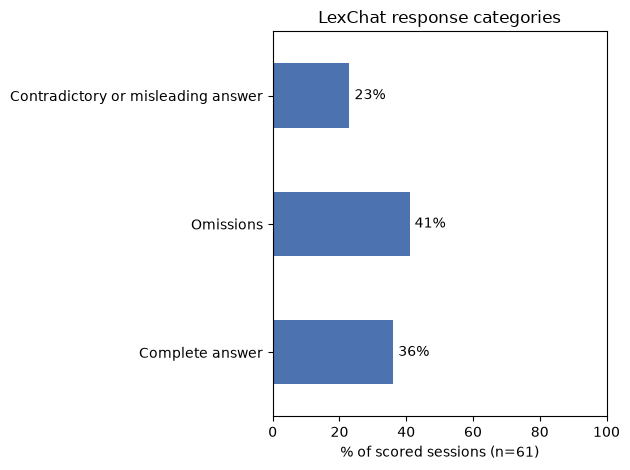

In [8]:
# Cell 5 — Aggregate rollup
import matplotlib.pyplot as plt

# Worst first, so the chart reads top-down from the failures.
CATEGORY_ORDER = [
    "Contradictory or misleading answer",
    "Omissions",
    "Complete answer",
]

# Two different non-verdicts: the model declined to judge, or the request never produced one.
NON_VERDICT_CATEGORIES = [ABSTAIN_CATEGORY, "Unclassified"]

classified = analysis_df[~analysis_df["category"].isin(NON_VERDICT_CATEGORIES)]
abstained = int(analysis_df["category"].eq(ABSTAIN_CATEGORY).sum())
failed = int(analysis_df["category"].eq("Unclassified").sum())
coverage = len(classified) / len(analysis_df) if len(analysis_df) else 0
print(
    f"Scored {len(classified)} of {len(analysis_df)} sessions ({coverage:.0%}). "
    f"Excluded from the shares below: {abstained} the model could not tell, "
    f"{failed} that failed to classify."
)

category_rollup = (
    classified["category"]
    .value_counts()
    .reindex(CATEGORY_ORDER, fill_value=0)
    .rename_axis("category")
    .reset_index(name="count")
)
category_rollup["percentage"] = (category_rollup["count"] / len(classified) * 100).round(1)
display(category_rollup)

# The reviewer's own confidence in the answer, named rather than picked by column order.
CATEGORY_SCORE_COLUMN = "Q8 confidence (1-5)"

if CATEGORY_SCORE_COLUMN in classified.columns:
    average_score = (
        classified.groupby("category")[CATEGORY_SCORE_COLUMN]
        .agg(mean="mean", n="count")
        .reindex(CATEGORY_ORDER)
        .round(2)
        .rename_axis("category")
        .reset_index()
    )
    average_score.insert(1, "score_column", CATEGORY_SCORE_COLUMN)
    display(average_score)
else:
    print(f"{CATEGORY_SCORE_COLUMN} is not in this export; skipping the score-by-category table.")

ax = category_rollup.plot(x="category", y="percentage", kind="barh", legend=False, color="#4c72b0")
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel(f"% of scored sessions (n={len(classified)})")
ax.set_ylabel("")
ax.set_title("LexChat response categories")
for y, value in enumerate(category_rollup["percentage"]):
    ax.text(value + 1.5, y, f"{value:.0f}%", va="center")
plt.tight_layout()
plt.show()

In [9]:
# Cell 6 — Model categories against the reviewers' own verdicts
# The reviewers already answered these questions themselves, so the classification can be checked
# against them. Note the model is shown the reviewer feedback, so this is a consistency check on
# the same evidence, not independent validation.
HUMAN_VERDICT_COLUMNS = [
    "Q5a found right law",
    "Q6a references accurate",
    "Q7a referred incorrectly",
]
VERDICT_FOR_CATEGORY = {
    "Complete answer": "yes",
    "Omissions": "partially",
    "Contradictory or misleading answer": "no",
}
AGREEMENT_COLUMN = "Q5a found right law"

for col in HUMAN_VERDICT_COLUMNS:
    if col not in classified.columns:
        continue
    table = (
        pd.crosstab(classified["category"], classified[col])
        .reindex(CATEGORY_ORDER, fill_value=0)
        .rename_axis(index="category", columns=col)
    )
    display(table[[v for v in ANSWER_ORDER if v in table.columns]])

if AGREEMENT_COLUMN in classified.columns:
    scored = classified[classified[AGREEMENT_COLUMN].notna()]
    model_flags = scored["category"].map(VERDICT_FOR_CATEGORY).ne("yes")
    human_flags = scored[AGREEMENT_COLUMN].ne("yes")
    print(
        f"Flagged a problem ({AGREEMENT_COLUMN} answered anything but yes): "
        f"model {model_flags.sum()}, reviewer {human_flags.sum()}, "
        f"agreeing on {(model_flags == human_flags).sum()} of {len(scored)} sessions "
        f"({(model_flags == human_flags).mean():.0%})."
    )
    print(
        f"Model flagged, reviewer did not: {(model_flags & ~human_flags).sum()}. "
        f"Reviewer flagged, model did not: {(~model_flags & human_flags).sum()}."
    )


Q5a found right law,yes,partially,no
category,,,
Contradictory or misleading answer,2,7,5
Omissions,8,11,6
Complete answer,20,2,0


Q6a references accurate,yes,partially,no
category,,,
Contradictory or misleading answer,9,3,2
Omissions,16,3,5
Complete answer,22,0,0


Q7a referred incorrectly,yes,partially,no
category,,,
Contradictory or misleading answer,3,5,6
Omissions,4,3,17
Complete answer,1,1,20


Flagged a problem (Q5a found right law answered anything but yes): model 39, reviewer 31, agreeing on 49 of 61 sessions (80%).
Model flagged, reviewer did not: 10. Reviewer flagged, model did not: 2.


## Are the reviewers' own scores consistent with what happened in the chat?

Everything above treats the reviewer feedback as evidence. This section tests the feedback itself.

Each session is read twice, once as a transcript and once as a survey return, and the question asked is
narrow: does what the reviewer reported match what the chat actually shows? Two columns are added to the
export.

- `user_consistency`, decided by this rule:
  - **consistent**, at least one material survey claim can be checked against the transcript, and no
    checkable claim is contradicted by it;
  - **inconsistent**, a rating or comment makes a factual claim about the session that the transcript
    disproves, or the survey contradicts itself;
  - **not possible to assess**, none of the material claims can be checked, either because they need
    outside legal knowledge or because the export is missing messages the reviewer saw.
- `consistency_rating_reason`, the evidence, drawn only from the chat interaction set against what the
  reviewer put in the ratings and comments. Where a self-report holds up, the reason says which turn
  supports it. Where it does not, the reason names the rating and the turn that contradicts it.

Four things deliberately do **not** decide the label, because the transcript cannot settle them: whether the
law in the answer is correct, faults the reviewer did not mention, subjective scores such as confidence and
ease of use, and estimated manual time or time saved. Estimated checking time is the one exception, and only
where the transcript shows the checking being done inside the session. A reason may still note these as
caveats, for example accuracy confirmed with zero checking time, since they are the self-report weaknesses
this analysis is looking for, but a caveat on its own never makes a session inconsistent.

The survey questions are scored as separate questions, not as duplicates of each other. A session can find
only part of the relevant law (Q5a) while still citing accurate references (Q6a), so an error reported in
one box does not have to appear in the others. On a session where nothing came back, a negative answer on
references or jurisdiction records that nothing usable was supplied, which is what the survey wording asks,
rather than a claim the chat disproves.

Unlike the categorisation above, these judgements were not produced by a call to the OpenRouter
classification model. Each of the 62 transcripts was read in full alongside its survey return, and the
results are stored in `notebooks/data/session_consistency_review.json`, keyed by `Response ID`. The next cell joins
that file onto the analysis frame, so re-running the notebook does not re-run the review. Three details
found while doing it are worth knowing when reading any of the tables above: the exported `Q7a referred
incorrectly` column is inverted relative to the survey's other accuracy questions, so "yes" means an
incorrect statement was found; `Q3 session continuity` asks whether the reviewer took a break between
queries, not whether the assistant answered without re-prompting; and four sessions (13, 55, 58 and 59)
export fewer messages than their own `Messages in thread` count, so part of what those reviewers saw is
missing from this file.

In [ ]:
# Cell 7 — Self-report consistency, joined from the reviewed file
CONSISTENCY_PATH = data_dir / "session_consistency_review.json"
CONSISTENCY_VALUES = ["consistent", "inconsistent", "not possible to assess"]

key = "Response ID" if "Response ID" in analysis_df.columns else "Session ID"
consistency = pd.read_json(CONSISTENCY_PATH).rename(columns={"response_id": key})


def check_consistency_file(reviewed, sessions, id_column):
    """Fail loudly on a malformed review file rather than exporting a bad join."""
    required = {id_column, "user_consistency", "consistency_rating_reason"}
    if not required.issubset(reviewed.columns):
        raise ValueError(f"Review file is missing columns: {sorted(required - set(reviewed.columns))}")

    duplicates = reviewed[id_column][reviewed[id_column].duplicated()].tolist()
    if duplicates:
        raise ValueError(f"Review file repeats {id_column}: {sorted(duplicates)}")

    bad_label = sorted(set(reviewed["user_consistency"]) - set(CONSISTENCY_VALUES))
    if bad_label:
        raise ValueError(f"Unexpected user_consistency values: {bad_label}")

    blank = reviewed.loc[reviewed["consistency_rating_reason"].fillna("").str.strip().eq(""), id_column]
    if len(blank):
        raise ValueError(f"Review file has empty reasons for: {sorted(blank)}")

    unknown = sorted(set(reviewed[id_column]) - set(sessions[id_column]))
    if unknown:
        raise ValueError(f"Review file has {id_column} values not in this export: {unknown}")

    return sorted(set(sessions[id_column]) - set(reviewed[id_column]))


unreviewed = check_consistency_file(consistency, analysis_df, key)
analysis_df = analysis_df.merge(consistency, on=key, how="left", validate="one_to_one")

print(f"Sessions reviewed: {analysis_df['user_consistency'].notna().sum()} of {len(analysis_df)}.")
if unreviewed:
    print(f"No consistency judgement (exports blank) for {key}: {unreviewed}")

rollup = (
    analysis_df["user_consistency"]
    .value_counts()
    .reindex(CONSISTENCY_VALUES, fill_value=0)
    .rename_axis("user_consistency")
    .reset_index(name="sessions")
)
rollup["percentage"] = (rollup["sessions"] / len(analysis_df) * 100).round(1)
display(rollup)

# The sessions that are not plainly consistent are the point of the exercise, so list them in full.
flagged = analysis_df[analysis_df["user_consistency"].isin(["inconsistent", "not possible to assess"])]
for _, row in flagged.iterrows():
    print(f"\n--- {key} {row[key]} ({row.get('User', 'unknown user')}): {row['user_consistency']}")
    print(row["consistency_rating_reason"])


In [ ]:
# Cell 8 — Export
input_path = Path(CSV_PATH)
OUTPUT_PATH = input_path.with_name(f"{input_path.stem}_categorized.csv")

# Keep the source columns, the two categorization fields, and the two consistency fields.
ADDED_COLUMNS = ["category", "rationale", "user_consistency", "consistency_rating_reason"]
export_columns = [c for c in original_columns if c in analysis_df.columns]
export_columns += [c for c in ADDED_COLUMNS if c in analysis_df.columns]
export_df = analysis_df[export_columns].copy()

# Models write curly quotes, em dashes and ellipses, which read as stray characters in a
# spreadsheet. Flatten them in the text this notebook generates. The pound sign is meaningful,
# so it stays, and the source columns are left exactly as exported.
TYPOGRAPHIC = {"’": "'", "‘": "'", "“": '"', "”": '"', "—": ", ", "–": "-", "…": "...", " ": " "}
MODEL_TEXT_COLUMNS = ["rationale", "consistency_rating_reason"]

for col in [c for c in MODEL_TEXT_COLUMNS if c in export_df.columns]:
    for bad, good in TYPOGRAPHIC.items():
        export_df[col] = export_df[col].str.replace(bad, good, regex=False)
    export_df[col] = export_df[col].str.replace(r"\s+", " ", regex=True).str.strip()

# utf-8-sig matches the LexChat export's own encoding, so Excel opens it as UTF-8.
export_df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

print(f"Saved {len(export_df)} rows to {OUTPUT_PATH}")
print("Added columns: " + ", ".join(c for c in ADDED_COLUMNS if c in export_df.columns))